# Preparation and Set up

## Import Necessary Resources

### Import Libraries

In [21]:
# Import necessary libraries
import sqlite3
from sqlite3 import Error
import kagglehub
import csv
import os

import pandas as pd
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

import ipywidgets as widgets
from IPython.display import display, Image, clear_output
from PIL import Image as PILImage
import io

### Import the Dataset into the Database

In [22]:
# Download the datasets
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")
# https://ieee-dataport.org/documents/deepguarddb-real-and-text-image-synthetic-images-dataset#files

# Connect to the SQLite database
conn = sqlite3.connect('image.db')

# Drop the test_images table if it exists
conn.execute(
                '''
                    DROP TABLE IF EXISTS test_images
                '''
)

# Drop the train_images table if it exists
conn.execute(
                '''
                    DROP TABLE IF EXISTS train_images
                '''
)

# Create the images table
conn.execute(
                '''
                    CREATE TABLE IF NOT EXISTS train_images(
                        image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
                        image_name TEXT NOT NULL,
                        image_label INTEGER NOT NULL
                    )
                '''
            )

# Create the test_images table
conn.execute(
                '''
                    CREATE TABLE IF NOT EXISTS test_images(
                        image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
                        image_name TEXT NOT NULL
                    )
                '''
            )

# Import the dataset into the database and create a list of labels
training_labels = []
# Import the training images
train_path = os.path.join(path, 'train.csv')
with open(train_path, 'r') as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    for row in reader:
        image_name = row[1]
        image_label = row[2]
        training_labels.append(image_label)
        if not image_name or not image_label: # Skip if image_name or image_label is empty
            continue
        conn.execute(
            '''
                INSERT INTO train_images (image_name, image_label)
                VALUES (?, ?)
            ''',
            (image_name, image_label)
        )
        
# Import the test images
test_path = os.path.join(path, 'test.csv')
with open(test_path, 'r') as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    for row in reader:
        if not image_name: # Skip if image_name is empty
            continue
        image_name = row[0]
        conn.execute(
            '''
                INSERT INTO test_images (image_name)
                VALUES (?)
            ''',
            (image_name,)
        )

# Commit the changes and close the connection
conn.commit()
conn.close()

## Prepare the Data

### Data Augmentation

In [45]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

### Create Data Pipelines

Tensor("args_0:0", shape=(), dtype=string)
Tensor("args_0:0", shape=(), dtype=string)


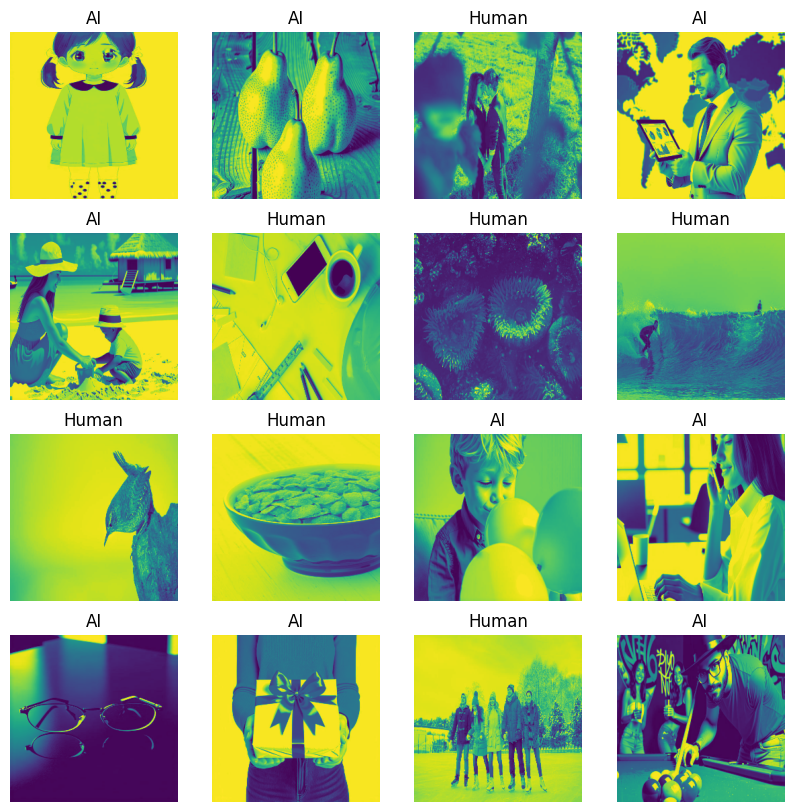

In [61]:
# Set the GPU memory growth to avoid OOM errors
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    
# Read the image data
def load_image(image_file, label=None):
    print(image_file)
    image_file = tf.squeeze(image_file)
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.resize(image, [250, 250])
    image = tf.cast(image, tf.float32) / 255.0
    
    return image, label

# Function to set dataset properties
def setup_dataset(dataset):
    dataset = dataset.map(load_image)
    dataset = dataset.shuffle(80000)
    dataset = dataset.batch(64).prefetch(tf.data.AUTOTUNE)
    return dataset

# Plot a batch of images
def plot_images(images, labels):
    plt.figure(figsize=(10, 10))
    # Plot 16 images in a 4x4 grid
    for i in range(16):
        # Determine the label for the image
        label = labels[i]
        if labels[i] == 1:
            label = 'AI'
        else:
            label = 'Human'
            
        # Create a subplot for each image
        ax = plt.subplot(4, 4, i + 1)
        # Load and display the image and label
        plt.imshow(images[i])
        plt.title(label)
        plt.axis('off')
    # Show the plot
    plt.show()

# Setup train dataset
train_df = pd.read_csv(train_path)
train_paths = [os.path.join(path, file) for file in train_df['file_name'].values]
train_labels = train_df['label'].values
train_images = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_images = setup_dataset(train_images)

# Setup test dataset
test_df = pd.read_csv(test_path)
test_paths = [os.path.join(path, file) for file in test_df['id'].values]
test_images = tf.data.Dataset.from_tensor_slices((test_paths))
test_images = setup_dataset(test_images)

data_iterator = train_images.as_numpy_iterator()
imgs, lbls = data_iterator.next()

# Create a function to plot images
plot_images(imgs, lbls)

### Define Data Partitions

In [24]:
train_size = int(len(train_images) * 0.7)
val_size = int(len(train_images) * 0.2)
test_size = len(test_images) - train_size - val_size

train_data = train_images.take(train_size)
val_data = train_images.skip(train_size).take(val_size)
test_data = train_images.skip(train_size + val_size).take(test_size)



## Create the Model

### Define Model

In [62]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(250,250,1)),
    data_augmentation,
    
    tf.keras.layers.Conv2D(16, (3,3), 1, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(64, (3,3), 1, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(16, (3,3), 1, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

### Compile Model

In [63]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

### Model Summary

In [64]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 250, 250, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 248, 248, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 124, 124, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 122, 122, 64)   │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 59, 59, 16)     │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 29, 29, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 13456)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     3,444,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,463,921 (13.21 MB)

 Trainable params: 3,463,921 (13.21 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [ ]:
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
history = model.fit(train_data, epochs=75, validation_data=val_data, callbacks=[tensorboard_callback])

Epoch 1/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 2744s 1s/step - accuracy: 0.7900 - loss: 0.5773 - val_accuracy: 0.8310 - val_loss: 0.3796
Epoch 2/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 3588s 2s/step - accuracy: 0.8556 - loss: 0.3447 - val_accuracy: 0.7057 - val_loss: 0.9089
Epoch 3/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 3485s 2s/step - accuracy: 0.9130 - loss: 0.2222 - val_accuracy: 0.5450 - val_loss: 2.5382
Epoch 4/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 2787s 1s/step - accuracy: 0.9356 - loss: 0.1679 - val_accuracy: 0.7573 - val_loss: 0.5915
Epoch 5/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 6814s 4s/step - accuracy: 0.9554 - loss: 0.1199 - val_accuracy: 0.8094 - val_loss: 0.4352
Epoch 6/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 2775s 1s/step - accuracy: 0.9631 - loss: 0.1021 - val_accuracy: 0.7965 - val_loss: 0.4958
Epoch 7/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 57197s 32s/step - accuracy: 0.9657 - loss: 0.0925 - val_accuracy: 0.9508 - val_loss: 0.1468
Epoch 8/20
1749/1749 ━━━━━━━━━━━━━━━━━━━━ 2623s 1s/step - accuracy: 0.9660

### Save the Model

In [33]:
model.save('AImageModelv2.keras')

### Load the Model

In [34]:
model = tf.keras.models.load_model('AImageModelv2.keras')

### Evaluate the Model

In [35]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()


for batch in test_data.as_numpy_iterator():
    x, y = batch
    prediction = model.predict(x)
    precision.update_state(y, prediction)
    recall.update_state(y, prediction)
    accuracy.update_state(y, prediction)
    
print(precision.result(), recall.result(), accuracy.result())
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

# Predictions

In [36]:
# Function to handle the upload event
def on_upload_change(change):
    with out:
        clear_output(wait=True)  # Clear previous output
        label.value = 'Uploaded Successfully'
        # Get the image and predict 
        uploaded_files = change['new']
        if uploaded_files:
            uploaded_file = uploaded_files[0]  # Get first file
            image_data = uploaded_file['content']  # Image as bytes
            
            # Convert image bytes to PIL grayscale (1 channel)
            pil_image = PILImage.open(io.BytesIO(image_data)).convert("L")

            
            # Resize the image to model's expected input shape
            pil_image = pil_image.resize((250, 250))  
            
            # Convert image to numpy array
            img_array = np.array(pil_image)
            
            # Normalize pixel values (assuming model expects values in range [0,1])
            img_array = img_array / 255.0  
            
            # Add batch dimension (assuming model expects shape: (batch_size, height, width, channels))
            img_array = np.expand_dims(img_array, axis=0)  

            # Make prediction
            prediction = model.predict(img_array)
            
            # Display the image
            display(pil_image)
            
            # Display the prediction result
            label.value = f"Value: {prediction[0][0]} Prediction: {'AI-Generated' if prediction[0][0] > 0.5 else 'Human-Created'}"
    
# Create an image upload widget
upload_btn = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',  # Acceptable file formats
    multiple=False  # Allow only one file at a time
)

# Create the Output widget to display the image
out = widgets.Output()

# Attach event listener
upload_btn.observe(on_upload_change, names='value')

# Set Label Value
label.value = ''

# Display the UI
display(upload_btn, label, out)


NameError: name 'label' is not defined

# Reporting and Visualizations

## Training Performance Over Time

### Loss While Training

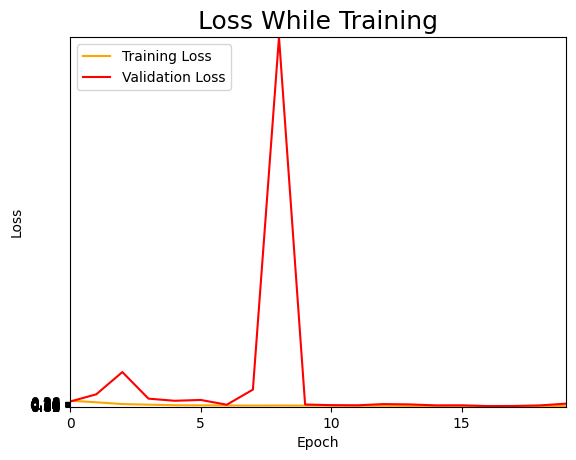

In [37]:
fig = plt.figure()
plt.plot(history.history['loss'], color='orange', label='Training Loss')
plt.plot(history.history['val_loss'], color='red', label='Validation Loss')
plt.margins(0)
plt.xticks(np.arange(0, 20, 5))
plt.yticks(np.arange(0,0.4,0.02))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Loss While Training", fontsize=18)
plt.legend(loc='upper left')
plt.show()

### Accuracy While Training

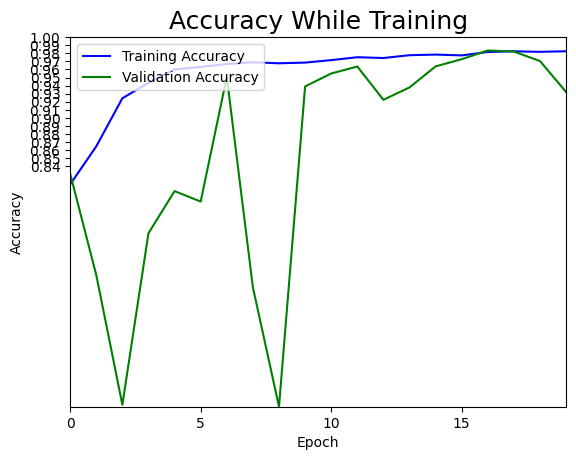

In [38]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='blue', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='green', label='Validation Accuracy')
plt.margins(0)
plt.xticks(np.arange(0, 20, 5))
plt.yticks(np.arange(0.84, 1, 0.01))
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Accuracy While Training", fontsize=18)
plt.legend(loc='upper left')
plt.show()